# Классификация кредитного рейтинга

Данные: [Credit Score Classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification): 100 тысяч строк с банковскими данными, нужно предсказать рейтинг клиента: Poor, Standard или Good.

Я начал с обычного подхода, как и в остальных публичных решениях: почистил данные, разбил на train и test, обучил бустинг, получил accuracy 0,77. Примерно столько же показывают публичные решения по этому датасету, там обычно около 80%.
Потом я посмотрел на данные внимательнее и заметил, что строк 100 тысяч, а уникальных клиентов 12,5 тысяч. Ровно восемь строк на человека, по одной на месяц. То есть при случайном разбиении по строкам один и тот же клиент почти наверняка попадает и в обучающую выборку, и в тестовую. Модель на тесте встречает людей, которых уже видела, и может опираться не на признаки риска, а на то, что она этого человека запомнила.
Дальше вся работа про то, чтобы это измерить. Я взял одну и ту же модель, одни и те же признаки, и обучил её дважды: на случайном разбиении по строкам и на разбиении по клиенту, где все восемь месяцев человека целиком уходят в одну часть.

| Разбиение | Общих клиентов | Accuracy | Macro-F1 | ROC-AUC | Gini |
|---|---|---|---|---|---|
| Случайное, по строкам | 11 299 из 12 500 | 0,7723 | 0,7590 | 0,9080 | 0,8161 |
| По клиенту | 0 | 0,6994 | 0,6762 | 0,8574 | 0,7147 |

Разница в Gini — 0,101, это 12,4% качества. Столько давала утечка, а не модель.

## 1. Импорты

In [25]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 2. Загрузка

Беру только `train.csv`. В `test.csv` из этого датасета целевой переменной нет, проверять на нём нечего, так что тестовую выборку выделю сам.

In [26]:
df = pd.read_csv("train.csv", low_memory=False)
print("Размер:", df.shape)
df.head(3)

Размер: (100000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good


## 3. Осмотр данных

In [27]:
df.groupby("Customer_ID").size().value_counts()

8    12500
Name: count, dtype: int64

In [28]:
print("Строк:", len(df))
print("Уникальных клиентов:", df["Customer_ID"].nunique())
print("Строк на клиента:", df.groupby("Customer_ID").size().value_counts())
print("Месяцы в данных:", sorted(df["Month"].unique()))
print("Распределение целевой переменной:")
print(df["Credit_Score"].value_counts(normalize=True).round(3))

Строк: 100000
Уникальных клиентов: 12500
Строк на клиента: 8    12500
Name: count, dtype: int64
Месяцы в данных: ['April', 'August', 'February', 'January', 'July', 'June', 'March', 'May']
Распределение целевой переменной:
Credit_Score
Standard    0.532
Poor        0.290
Good        0.178
Name: proportion, dtype: float64


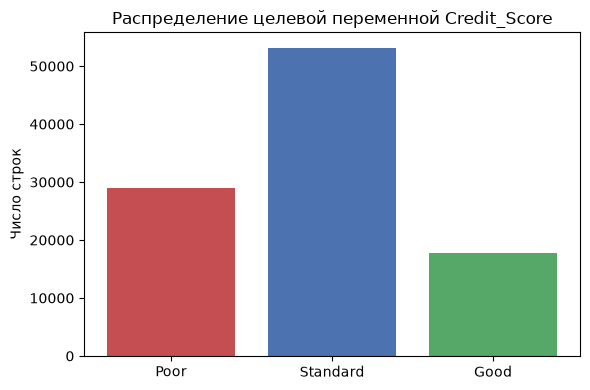

In [29]:
order = ["Poor", "Standard", "Good"]
counts = df["Credit_Score"].value_counts().reindex(order)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color=["#c44e52", "#4c72b0", "#55a868"])
plt.ylabel("Число строк")
plt.title("Распределение целевой переменной Credit_Score")
plt.tight_layout()
plt.show()

### Что получилось

Строк 100 тысяч, клиентов 12.5 тысяч, ровно по восемь строк на каждого: январь по август. Восемь строк одного человека почти одинаковые: возраст, профессия, доход и большая часть кредитной истории у него между месяцами не меняются. Значит, строки не являются независимыми наблюдениями, и обычный train_test_split здесь работает не так, как кажется. Прикинем, насколько всё плохо. Если разбивать случайно по строкам с долей теста $\alpha$, то все восемь строк клиента попадут в одну часть с вероятностью $P = \alpha^8 + (1-\alpha)^8$

При $\alpha = 0.25$ это примерно $0.1$. То есть у 90% клиентов часть месяцев уйдёт в обучение, а часть в тест. Ниже, в разделе 11, я проверил этот расчёт прямо на данных: общих клиентов оказалось 11 299 из 12 500, то есть 90,4%. Сошлось. Отсюда же следует ещё одна вещь, которая пригодится дальше. Почти все решения по этому датасету заполняют пропуски значением того же клиента за другой месяц. Приём разумный, но корректный он только если сплит уже сделан по клиенту. Иначе значение из тестовой строки протекает в обучающую.

## 4. Чистка типов

Датасет специально испорчен. Числа записаны строками с подчёркиваниями (`_23`, `28_`), встречаются заглушки вроде `!@9#%8` и `_______`, а стаж кредитной истории лежит текстом: `"22 Years and 1 Months"`. Обрезаю мусорные символы по краям строк и превращаю заглушки в пропуски.

In [30]:
str_cols = ["Month", "Name", "Age", "SSN", "Occupation", "Annual_Income",
            "Num_of_Loan", "Type_of_Loan", "Num_of_Delayed_Payment",
            "Changed_Credit_Limit", "Credit_Mix", "Outstanding_Debt",
            "Credit_History_Age", "Payment_of_Min_Amount", "Amount_invested_monthly",
            "Payment_Behaviour", "Monthly_Balance"]

for c in str_cols:
    df[c] = df[c].astype("string").str.strip('_ ,"')

junk = ["", "nan", "!@9#%8", "#F%$D@*&8", "_______", "_", "NM"]
df = df.replace(junk, np.nan)

print("Пропусков после чистки заглушек:")
print(df.isna().sum()[df.isna().sum() > 0].sort_values(ascending=False))

Пропусков после чистки заглушек:
Credit_Mix                 20195
Monthly_Inhand_Salary      15002
Payment_of_Min_Amount      12007
Type_of_Loan               11408
Name                        9985
Credit_History_Age          9030
Payment_Behaviour           7600
Occupation                  7062
Num_of_Delayed_Payment      7002
SSN                         5572
Amount_invested_monthly     4479
Changed_Credit_Limit        2091
Num_Credit_Inquiries        1965
Monthly_Balance             1200
dtype: int64


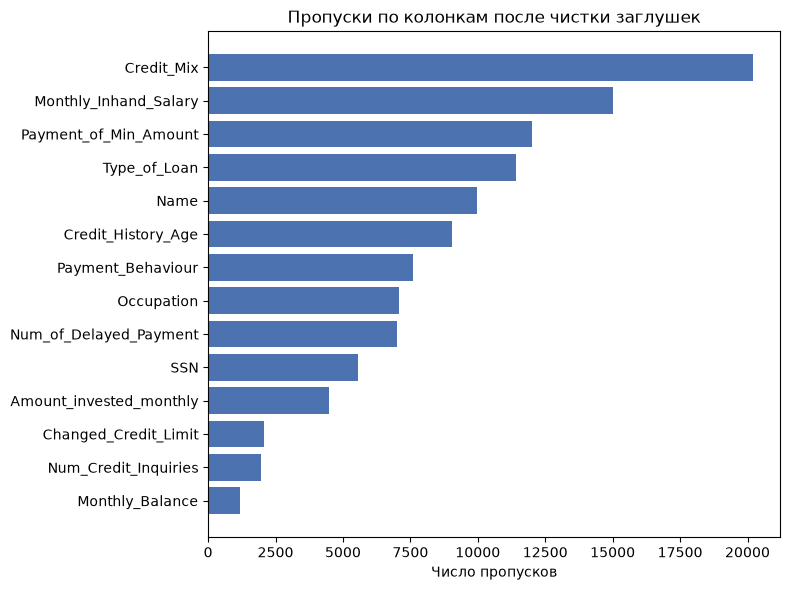

In [31]:
na_counts = df.isna().sum()
na_counts = na_counts[na_counts > 0].sort_values(ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(na_counts.index, na_counts.values, color="#4c72b0")
plt.xlabel("Число пропусков")
plt.title("Пропуски по колонкам после чистки заглушек")
plt.tight_layout()
plt.show()

Дальше перевожу числовые колонки в числа. `errors="coerce"` отправляет всё непарсящееся в `NaN`. Vолча терять такие значения не хочется, но и падать на них смысла нет, дальше разберусь с ними как с пропусками. `Credit_History_Age` разбираю отдельно: из строки `"22 Years and 1 Months"` считаю общее число месяцев. Так признак становится обычным числовым и годится для линейной модели.

In [32]:
num_cols = ["Age", "Annual_Income", "Monthly_Inhand_Salary", "Num_Bank_Accounts",
            "Num_Credit_Card", "Interest_Rate", "Num_of_Loan", "Delay_from_due_date",
            "Num_of_Delayed_Payment", "Changed_Credit_Limit", "Num_Credit_Inquiries",
            "Outstanding_Debt", "Credit_Utilization_Ratio", "Total_EMI_per_month",
            "Amount_invested_monthly", "Monthly_Balance"]

for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").astype("float64")


years = df["Credit_History_Age"].str.extract(r"(\d+)\s+Years", expand=False).astype(float)
months = df["Credit_History_Age"].str.extract(r"(\d+)\s+Months", expand=False).astype(float)
df["Credit_History_Age"] = years * 12 + months
num_cols.append("Credit_History_Age")

month_map = {"January": 1, "February": 2, "March": 3, "April": 4,
             "May": 5, "June": 6, "July": 7, "August": 8}
df["Month"] = df["Month"].map(month_map)

df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,100000.0,1.106497e+02,6.862447e+02,-5.000000e+02,24.000000,33.000000,42.000000,8.698000e+03
Annual_Income,100000.0,1.764157e+05,1.429618e+06,7.005930e+03,19457.500000,37578.610000,72790.920000,2.419806e+07
Monthly_Inhand_Salary,84998.0,4.194171e+03,3.183686e+03,3.036454e+02,1625.568229,3093.745000,5957.448333,1.520463e+04
Num_Bank_Accounts,100000.0,1.709128e+01,1.174048e+02,-1.000000e+00,3.000000,6.000000,7.000000,1.798000e+03
Num_Credit_Card,100000.0,2.247443e+01,1.290574e+02,0.000000e+00,4.000000,5.000000,7.000000,1.499000e+03
Interest_Rate,100000.0,7.246604e+01,4.664226e+02,1.000000e+00,8.000000,13.000000,20.000000,5.797000e+03
Num_of_Loan,100000.0,3.009960e+00,6.264788e+01,-1.000000e+02,1.000000,3.000000,5.000000,1.496000e+03
Delay_from_due_date,100000.0,2.106878e+01,1.486010e+01,-5.000000e+00,10.000000,18.000000,28.000000,6.700000e+01
Num_of_Delayed_Payment,92998.0,3.092334e+01,2.260319e+02,-3.000000e+00,9.000000,14.000000,18.000000,4.397000e+03
Changed_Credit_Limit,97909.0,1.038903e+01,6.789496e+00,-6.490000e+00,5.320000,9.400000,14.870000,3.697000e+01


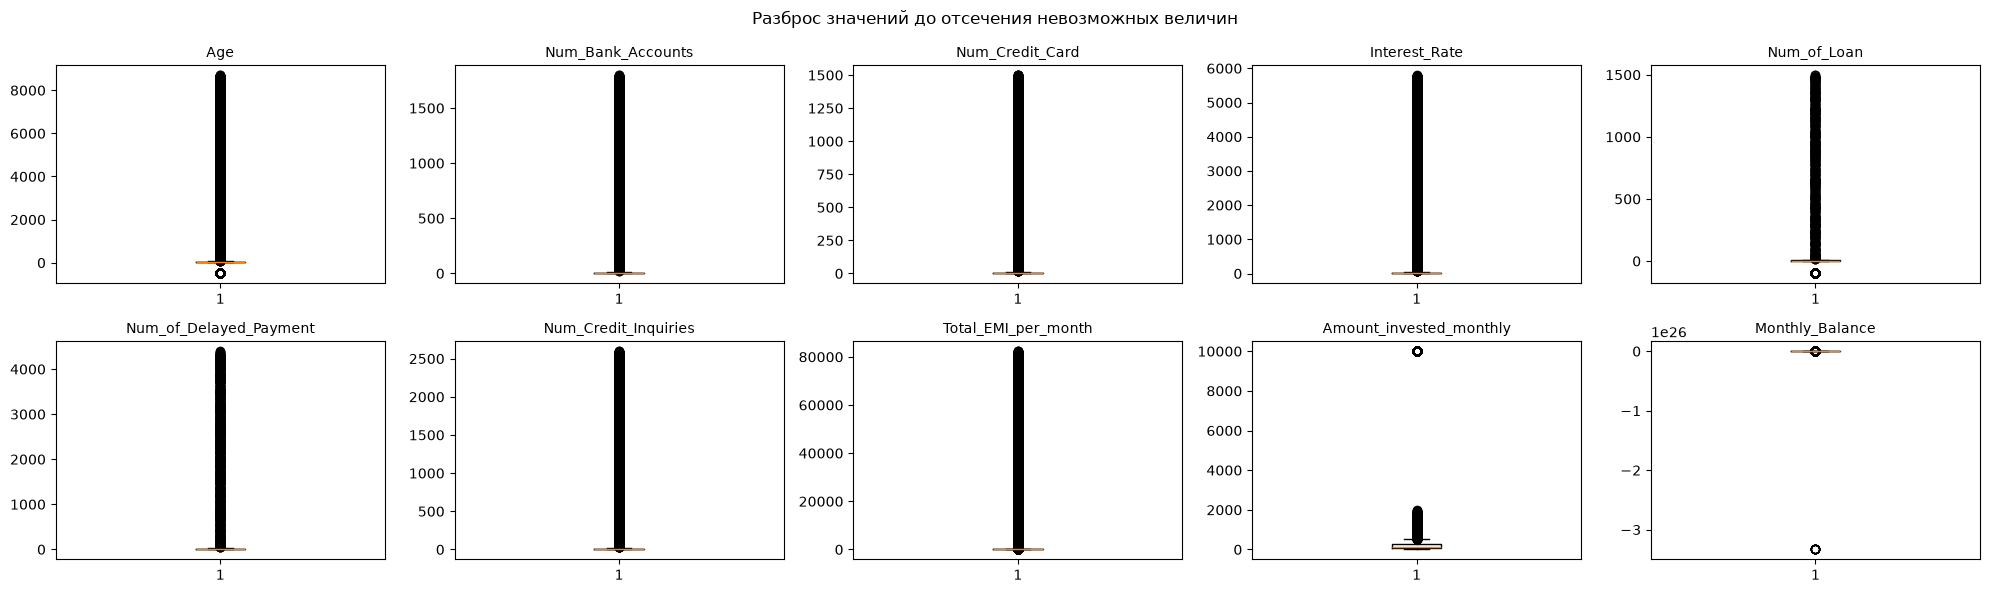

In [33]:
outlier_prone = ["Age", "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
                 "Num_of_Loan", "Num_of_Delayed_Payment", "Num_Credit_Inquiries",
                 "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"]

fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for col, ax in zip(outlier_prone, axes.ravel()):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=10)
fig.suptitle("Разброс значений до отсечения невозможных величин")
plt.tight_layout()
plt.show()

## 5. Невозможные значения

В `describe()` выше видно возраст 8698 лет, 1798 банковских счетов, пять с лишним тысяч просроченных платежей. Это не выбросы, это испорченные записи. Обычно такие строки просто выкидывают. Я так делать не стал по двум причинам. Во-первых, у клиента восемь строк, и выбросив три из них, я получу рваную историю. Во-вторых, если так фильтровать по десятку колонок подряд, незаметно уходит заметная часть выборки, и распределение целевой переменной смещается. Вместо этого помечаю такие значения как пропуски и заполняю на следующем шаге. Клиент при этом остаётся в данных целиком.

In [34]:
limits = {
    "Age": (18, 100),
    "Num_Bank_Accounts": (0, 20),
    "Num_Credit_Card": (0, 20),
    "Interest_Rate": (0, 50),
    "Num_of_Loan": (0, 15),
    "Num_of_Delayed_Payment": (0, 100),
    "Num_Credit_Inquiries": (0, 50),
    "Total_EMI_per_month": (0, 5000),
    "Amount_invested_monthly": (0, 2000),
    "Monthly_Balance": (0, 2000),
}

before = df[list(limits)].isna().sum().sum()
for c, (lo, hi) in limits.items():
    df.loc[(df[c] < lo) | (df[c] > hi), c] = np.nan
after = df[list(limits)].isna().sum().sum()

print(f"Помечено как пропуск: {after - before} значений")
print(f"Строк потеряно: 0 (в этом и смысл)")
df[list(limits)].describe().T

Помечено как пропуск: 28766 значений
Строк потеряно: 0 (в этом и смысл)


,count,mean,std,min,25%,50%,75%,max
Age,91518.0,34.429817,10.123827,18.00000,26.000000,34.000000,42.000000,100.000000
Num_Bank_Accounts,98665.0,5.369108,2.592749,0.00000,3.000000,5.000000,7.000000,18.000000
Num_Credit_Card,97737.0,5.534219,2.070051,0.00000,4.000000,5.000000,7.000000,20.000000
Interest_Rate,97966.0,14.531603,8.739748,1.00000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,95652.0,3.533758,2.447308,0.00000,2.000000,3.000000,5.000000,9.000000
Num_of_Delayed_Payment,91630.0,13.427491,6.248467,0.00000,9.000000,14.000000,18.000000,98.000000
Num_Credit_Inquiries,96401.0,5.786133,3.881031,0.00000,3.000000,5.000000,8.000000,49.000000
Total_EMI_per_month,97012.0,111.983968,180.676679,0.00000,29.371497,66.603729,147.792533,4991.000000
Amount_invested_monthly,91216.0,195.539456,199.564527,0.00000,72.236692,128.954538,236.815814,1977.326102
Monthly_Balance,98791.0,402.551258,213.925499,0.00776,270.106630,336.731225,470.262938,1602.040519


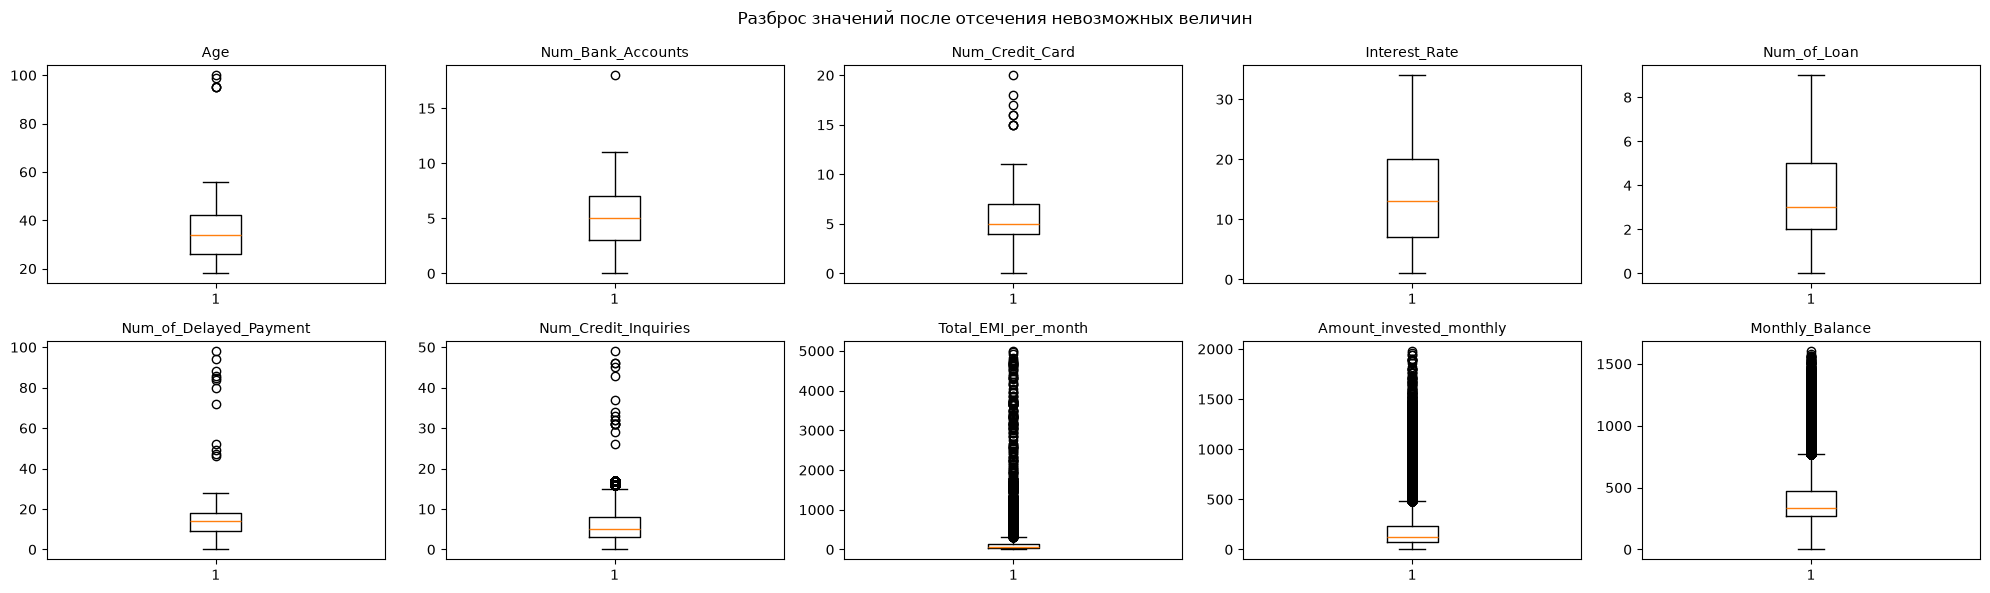

In [35]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for col, ax in zip(limits, axes.ravel()):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=10)
fig.suptitle("Разброс значений после отсечения невозможных величин")
plt.tight_layout()
plt.show()

## 6. Признаки из `Type_of_Loan`

Это список кредитов через запятую, вида: Auto Loan, and Personal Loan. Разворачиваю в бинарные признаки. Заодно выбрасываю `ID`, `Name` и `SSN`. Это идентификаторы, модель по ним просто запомнит конкретных людей

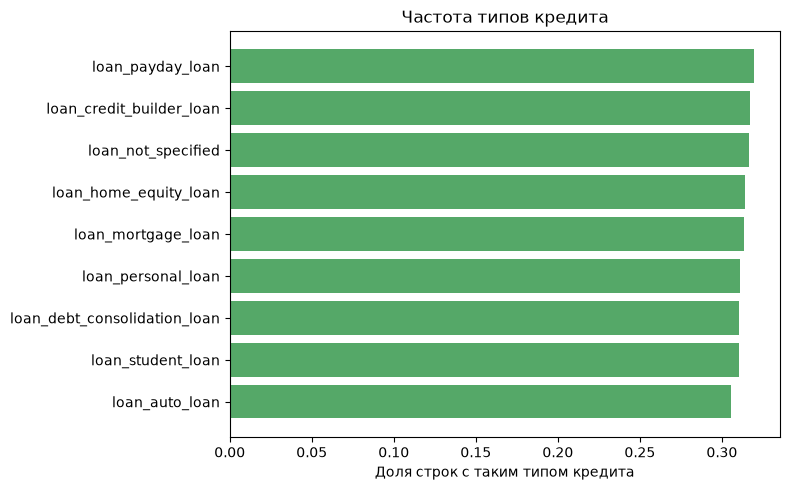

In [36]:
loan_types = ["Auto Loan", "Credit-Builder Loan", "Personal Loan", "Home Equity Loan",
              "Mortgage Loan", "Student Loan", "Debt Consolidation Loan",
              "Payday Loan", "Not Specified"]

tl = df["Type_of_Loan"].fillna("")
loan_flag_cols = []
for t in loan_types:
    col = "loan_" + t.lower().replace(" ", "_").replace("-", "_")
    df[col] = tl.str.contains(t, regex=False).astype(int)
    loan_flag_cols.append(col)

df["n_loan_types"] = df[loan_flag_cols].sum(axis=1)
df = df.drop(columns=["ID", "Name", "SSN", "Type_of_Loan"])


loan_means = df[loan_flag_cols].mean().sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(loan_means.index, loan_means.values, color="#55a868")
plt.xlabel("Доля строк с таким типом кредита")
plt.title("Частота типов кредита")
plt.tight_layout()
plt.show()

## 7. Разбиение по клиенту

Главный шаг. `GroupShuffleSplit` следит за тем, чтобы все строки одного `Customer_ID` ушли целиком в одну часть. Делаю это прямо сейчас, до заполнения пропусков и до обучения кодировщиков. Любое преобразование, которое считает что-то по данным — медиану, среднее, набор категорий, масштаб, — должно видеть только train. Иначе информация о тесте попадает в модель ещё до обучения. В публичных решениях по этому датасету `MinMaxScaler` и `PCA` обычно применяют ко всей выборке сразу, и это вторая утечка поверх первой. Ниже сразу проверяю, что клиенты действительно не пересекаются.

In [37]:
y = df["Credit_Score"].map({"Poor": 0, "Standard": 1, "Good": 2})
X = df.drop(columns=["Credit_Score"])
groups = df["Customer_ID"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(X_train["Customer_ID"]) & set(X_test["Customer_ID"])
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Клиентов в train:", X_train["Customer_ID"].nunique(),
      "| в test:", X_test["Customer_ID"].nunique())
print("Пересечение клиентов:", len(overlap))

Train: (75000, 33) | Test: (25000, 33)
Клиентов в train: 9375 | в test: 3125
Пересечение клиентов: 0


## 8. Заполнение пропусков

Часть признаков у одного человека постоянна во всех восьми месяцах: доход, профессия, стаж кредитной истории. Поэтому пропуск логичнее заполнить его же значением за другой месяц, а не общей медианой тк так точнее. Теперь это безопасно. После группового сплита все восемь строк клиента лежат по одну сторону границы, и такое заполнение ничего не тянет из теста в обучение. Остаток это клиенты, у которых признак пропущен во всех месяцах сразу. Их заполняю медианой и модой, посчитанными только по train.

In [38]:
cat_cols = ["Occupation", "Credit_Mix", "Payment_of_Min_Amount", "Payment_Behaviour"]

for part in (X_train, X_test):
    for c in num_cols:
        part[c] = part[c].fillna(part.groupby("Customer_ID")[c].transform("median"))
    for c in cat_cols:
        part[c] = part[c].fillna(part.groupby("Customer_ID")[c].transform(
            lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan))

train_medians = X_train[num_cols].median()
train_modes = {c: X_train[c].mode().iloc[0] for c in cat_cols}

X_train[num_cols] = X_train[num_cols].fillna(train_medians)
X_test[num_cols] = X_test[num_cols].fillna(train_medians)
for c in cat_cols:
    X_train[c] = X_train[c].fillna(train_modes[c])
    X_test[c] = X_test[c].fillna(train_modes[c])

for c in cat_cols:
    X_train[c] = X_train[c].astype(str)
    X_test[c] = X_test[c].astype(str)

X_train = X_train.drop(columns=["Customer_ID"])
X_test = X_test.drop(columns=["Customer_ID"])

print("Пропусков в train:", int(X_train.isna().sum().sum()))
print("Пропусков в test: ", int(X_test.isna().sum().sum()))

Пропусков в train: 0
Пропусков в test:  0


## 9. Кодирование

Категориальные признаки кодирую через `OneHotEncoder`. Числовые масштабирую. Всё складываю в `Pipeline`, чтобы преобразования обучались строго на train.

In [39]:
feature_num = num_cols + loan_flag_cols + ["n_loan_types", "Month"]
feature_cat = cat_cols

preprocess = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("sc", StandardScaler())]), feature_num),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), feature_cat),
])

print("Числовых признаков:", len(feature_num))
print("Категориальных:", len(feature_cat))

Числовых признаков: 28
Категориальных: 4


## 10. С чем сравнивать

Прежде чем радоваться качеству модели, полезно знать точку отсчёта. Класс `Standard` занимает 53% выборки, значит константный прогноз даст accuracy около 0,53. Именно на этом фоне надо читать «80%» из публичных решений.

Одной accuracy при таком дисбалансе мало, поэтому смотрю ещё три метрики. Macro-F1 усредняет F1 по классам без учёта их размера, так что редкий `Good` не растворяется в большом `Standard`. ROC-AUC не зависит от выбранного порога. И Gini, который в кредитном риске используют чаще всего: $Gini = 2 \cdot AUC - 1$ Он равен нулю у случайной модели и единице у идеальной, поэтому качество удобно обсуждать именно в нём.

In [40]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print("Baseline accuracy (константный прогноз):",
      round(accuracy_score(y_test, dummy.predict(X_test)), 4))

Baseline accuracy (константный прогноз): 0.5312


### Логистическая регрессия

In [41]:
logreg = Pipeline([("prep", clone(preprocess)),
                   ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))])
logreg.fit(X_train, y_train)

pred = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)
auc = roc_auc_score(y_test, proba, multi_class="ovr", average="macro")

print("Логистическая регрессия")
print("  Accuracy:", round(accuracy_score(y_test, pred), 4))
print("  Macro-F1:", round(f1_score(y_test, pred, average="macro"), 4))
print("  ROC-AUC :", round(auc, 4))
print("  Gini    :", round(2 * auc - 1, 4))
print()
print(classification_report(y_test, pred, target_names=["Poor", "Standard", "Good"], zero_division=0))

Логистическая регрессия
  Accuracy: 0.6634
  Macro-F1: 0.6429
  ROC-AUC : 0.8193
  Gini    : 0.6385

              precision    recall  f1-score   support

        Poor       0.65      0.56      0.60      7177
    Standard       0.70      0.72      0.71     13280
        Good       0.57      0.67      0.61      4543

    accuracy                           0.66     25000
   macro avg       0.64      0.65      0.64     25000
weighted avg       0.67      0.66      0.66     25000



### Градиентный бустинг

Вторая модель — бустинг на деревьях, он ловит нелинейности и взаимодействия признаков.

Гнать семь моделей подряд я не стал. Линейная модель и бустинг закрывают обе крайности по гибкости, а всё, что между ними, к выводам ничего не добавит — только удлинит ноутбук.

In [42]:
boost = Pipeline([("prep", clone(preprocess)),
                  ("clf", HistGradientBoostingClassifier(
                      max_iter=300, learning_rate=0.1,
                      early_stopping=True, validation_fraction=0.1,
                      random_state=RANDOM_STATE))])
boost.fit(X_train, y_train)

pred_b = boost.predict(X_test)
proba_b = boost.predict_proba(X_test)
auc_b = roc_auc_score(y_test, proba_b, multi_class="ovr", average="macro")

print("Градиентный бустинг")
print("  Accuracy:", round(accuracy_score(y_test, pred_b), 4))
print("  Macro-F1:", round(f1_score(y_test, pred_b, average="macro"), 4))
print("  ROC-AUC :", round(auc_b, 4))
print("  Gini    :", round(2 * auc_b - 1, 4))
print()
print(classification_report(y_test, pred_b, target_names=["Poor", "Standard", "Good"], zero_division=0))

Градиентный бустинг
  Accuracy: 0.7044
  Macro-F1: 0.6817
  ROC-AUC : 0.862
  Gini    : 0.7241

              precision    recall  f1-score   support

        Poor       0.71      0.68      0.69      7177
    Standard       0.74      0.75      0.74     13280
        Good       0.60      0.62      0.61      4543

    accuracy                           0.70     25000
   macro avg       0.68      0.68      0.68     25000
weighted avg       0.70      0.70      0.70     25000



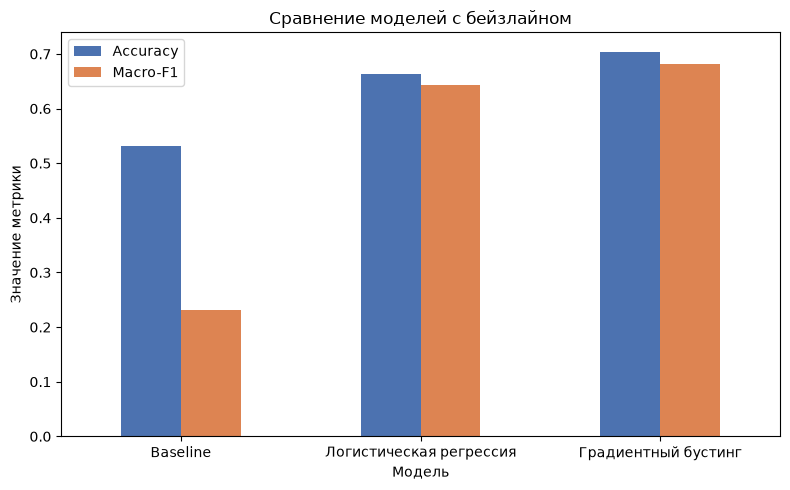

In [43]:
model_metrics = pd.DataFrame([
    {"Модель": "Baseline",
     "Accuracy": accuracy_score(y_test, dummy.predict(X_test)),
     "Macro-F1": f1_score(y_test, dummy.predict(X_test), average="macro")},
    {"Модель": "Логистическая регрессия",
     "Accuracy": accuracy_score(y_test, pred),
     "Macro-F1": f1_score(y_test, pred, average="macro")},
    {"Модель": "Градиентный бустинг",
     "Accuracy": accuracy_score(y_test, pred_b),
     "Macro-F1": f1_score(y_test, pred_b, average="macro")},
]).set_index("Модель")

ax = model_metrics.plot(kind="bar", figsize=(8, 5), color=["#4c72b0", "#dd8452"], rot=0)
ax.set_ylabel("Значение метрики")
ax.set_title("Сравнение моделей с бейзлайном")
plt.tight_layout()
plt.show()

## 11. Два разбиения, одна модель

Всё предыдущее было подготовкой к этому месту. Обучаю одну и ту же модель на одних и тех же данных дважды, различается только способ разбиения:

- случайно по строкам, как в большинстве публичных решений — клиент попадает и в train, и в test;
- по клиенту.

Разница между строками таблицы и есть та часть качества, которая берётся из утечки.

In [44]:
Xg = X.drop(columns=["Customer_ID"]).copy()
# Оба плеча эксперимента обрабатываем одинаково и без импутации по клиенту:
# единственное различие между строками таблицы должно быть в способе разбиения.
for c in cat_cols:
    Xg[c] = Xg[c].fillna("Unknown").astype(str)

results = []

for name, (tr, te) in [
    ("Наивный сплит (по строкам)",
     train_test_split(np.arange(len(Xg)), test_size=0.25, random_state=RANDOM_STATE)),
    ("Сплит по клиенту",
     next(GroupShuffleSplit(n_splits=1, test_size=0.25,
                            random_state=RANDOM_STATE).split(Xg, y, groups=groups))),
]:
    Xtr, Xte = Xg.iloc[tr], Xg.iloc[te]
    ytr, yte = y.iloc[tr], y.iloc[te]

    m = Pipeline([("prep", clone(preprocess)),
                  ("clf", HistGradientBoostingClassifier(
                      max_iter=300, learning_rate=0.1, early_stopping=True,
                      validation_fraction=0.1, random_state=RANDOM_STATE))])
    m.fit(Xtr, ytr)

    p = m.predict(Xte)
    pr = m.predict_proba(Xte)
    a = roc_auc_score(yte, pr, multi_class="ovr", average="macro")
    shared = len(set(groups.iloc[tr]) & set(groups.iloc[te]))

    results.append({
        "Разбиение": name,
        "Общих клиентов": shared,
        "Accuracy": round(accuracy_score(yte, p), 4),
        "Macro-F1": round(f1_score(yte, p, average="macro"), 4),
        "ROC-AUC": round(a, 4),
        "Gini": round(2 * a - 1, 4),
    })

pd.DataFrame(results)

,Разбиение,Общих клиентов,Accuracy,Macro-F1,ROC-AUC,Gini
0,Наивный сплит (по строкам),11299,0.7723,0.7590,0.9080,0.8161
1,Сплит по клиенту,0,0.6994,0.6762,0.8574,0.7147


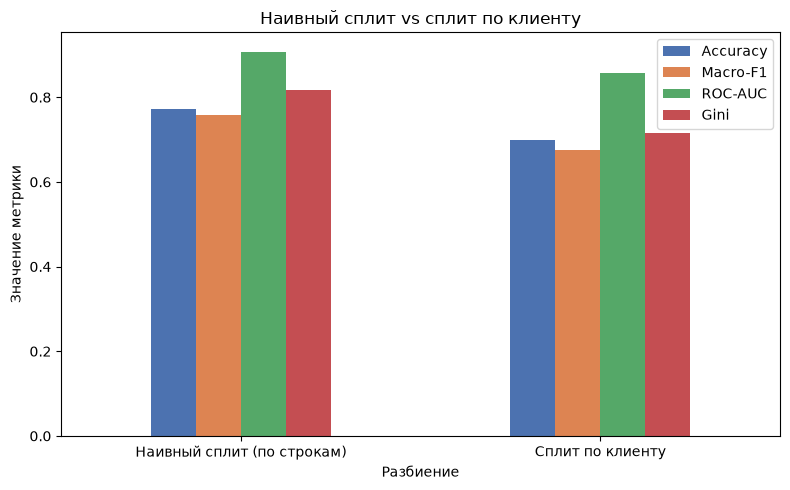

In [45]:
split_metrics = pd.DataFrame(results).set_index("Разбиение")[["Accuracy", "Macro-F1", "ROC-AUC", "Gini"]]

ax = split_metrics.plot(kind="bar", figsize=(8, 5), rot=0,
                        color=["#4c72b0", "#dd8452", "#55a868", "#c44e52"])
ax.set_ylabel("Значение метрики")
ax.set_title("Наивный сплит vs сплит по клиенту")
plt.tight_layout()
plt.show()

### Что видно в таблице

Столбец «Общих клиентов» показывает механизм напрямую: при случайном разбиении 11 299 клиентов из 12 500 присутствуют одновременно в обучении и тесте. Это 90,4% — расчёт из раздела 3 давал 90,0%, так что формула совпала с данными почти точно.

Сколько это стоит:

| Метрика | Случайный сплит | По клиенту | Разница |
|---|---|---|---|
| Accuracy | 0,7723 | 0,6994 | −7,3 п.п. |
| Macro-F1 | 0,7590 | 0,6762 | −8,3 п.п. |
| ROC-AUC | 0,9080 | 0,8574 | −0,051 |
| Gini | 0,8161 | 0,7147 | −0,101 |

Accuracy при случайном разбиении — 0,77, то есть примерно те самые 80%, которые публикуют по этому датасету. После честного разбиения остаётся 0,70 при базовых 0,53.

Ноль с небольшим по Gini звучит скромно, но для кредитного риска 0,101 — это много: разница между хорошей и посредственной моделью на портфеле обычно того же порядка.

Отдельно стоит сказать про то, почему такую ошибку легко не заметить. Изнутри эксперимента она не видна вообще: отложенная выборка выглядит нормально, кросс-валидация даёт стабильные цифры, ничего не сигнализирует о проблеме. Найти её можно только зная, как устроены данные — поэтому осмотр в разделе 3 был не формальностью.

Ещё одна мелочь: в разделе 10 бустинг на групповом разбиении дал Gini 0,7241, а здесь 0,7147. Разница в том, что в этом эксперименте я не применяю заполнение пропусков по клиенту — оба плеча должны отличаться только сплитом. Получается, та импутация стоила примерно 0,009 Gini.

## 12. Какие признаки работают

Смотрю permutation_importance: значения признака случайно перемешиваются, и измеряется, насколько просела метрика. В отличие от встроенной важности деревьев, этот способ не завышает вклад признаков с большим числом уникальных значений. Взял подвыборку для ускорения рассчетов

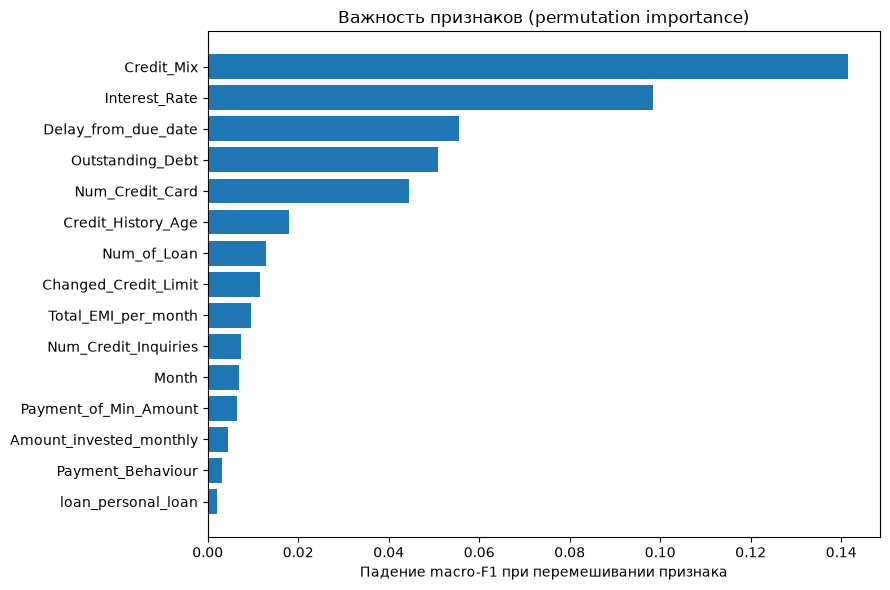

,Признак,Падение macro-F1
13,Credit_Mix,0.141501
7,Interest_Rate,0.098331
9,Delay_from_due_date,0.055500
14,Outstanding_Debt,0.050805
6,Num_Credit_Card,0.044535
16,Credit_History_Age,0.017967
8,Num_of_Loan,0.012963
11,Changed_Credit_Limit,0.011514
18,Total_EMI_per_month,0.009614
12,Num_Credit_Inquiries,0.007251


In [46]:
sub = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=min(5000, len(X_test)), replace=False)
imp = permutation_importance(boost, X_test.iloc[sub], y_test.iloc[sub],
                             n_repeats=5, random_state=RANDOM_STATE, scoring="f1_macro")

imp_df = (pd.DataFrame({"Признак": X_test.columns, "Падение macro-F1": imp.importances_mean})
          .sort_values("Падение macro-F1", ascending=False).head(15))

plt.figure(figsize=(9, 6))
plt.barh(imp_df["Признак"][::-1], imp_df["Падение macro-F1"][::-1])
plt.xlabel("Падение macro-F1 при перемешивании признака")
plt.title("Важность признаков (permutation importance)")
plt.tight_layout()
plt.show()

imp_df

### Что из этого следует

Порядок признаков вышел осмысленный: тип кредитного портфеля, ставка, просрочки, размер долга.

`Credit_Mix` оторвался от всех остальных: 0,142 против 0,098 у следующего. Это настораживает: по сути это уже готовая экспертная оценка качества кредитного набора клиента, то есть признак, стоящий очень близко к целевой переменной. В реальной задаче его пришлось бы отдельно проверять на доступность в момент принятия решения по заявке. Если он появляется уже после решения, использовать его нельзя тк это была бы утечка, только другого рода: не через группу, а из будущего.

Дальше идут `Interest_Rate` (ставка косвенно отражает риск, присвоенный клиенту раньше), `Delay_from_due_date` и `Outstanding_Debt`. Просрочка и долговая нагрузка, самые прямые поведенческие признаки.

А вот флаги типов кредита не сработали совсем: вклад около 0,002. Разворачивание `Type_of_Loan` в девять бинарных колонок оказалось лишней работой. В следующий раз я бы вместо этого попробовал число активных кредитов и их суммарный объём.

## 13. Матрица ошибок

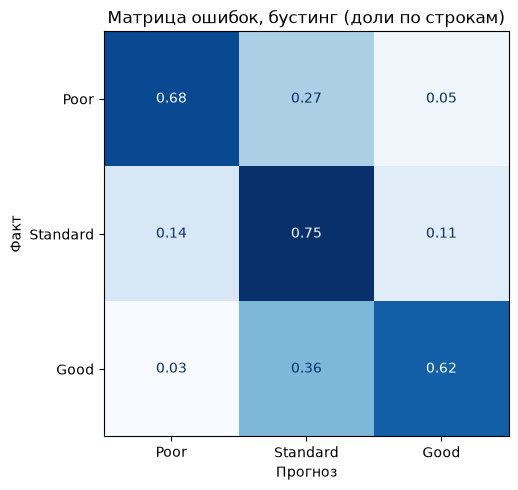

In [47]:
cm = confusion_matrix(y_test, pred_b, normalize="true")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Poor", "Standard", "Good"]).plot(
    ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
ax.set_title("Матрица ошибок, бустинг (доли по строкам)")
ax.set_xlabel("Прогноз")
ax.set_ylabel("Факт")
plt.tight_layout()
plt.show()

## 14. Итоги

Что сделано по методологии:

 - 12,5 тысяч клиентов по восемь месяцев. Случайное разбиение по строкам оставляет клиента одновременно в обучении и тесте в 90,4% случаев, что почти в точности совпало с расчётом из раздела 3. Выполнено корректное разбиение по клиенту, и утечка стоит 0,101 Gini: 0,8161 против 0,7147, то есть 12,4% качества.
- Заполнение пропусков по другим месяцам клиента я делал только после группового сплита, а все статистики считал по train. Само по себе оно добавляет около 0,009 Gini.
- Испорченные значения 28 766 штук помечены как пропуски, а не удалены вместе со строками. Строк потеряно ноль.
- Категории закодированы one-hot

Что получилось по качеству на честном разбиении:

| Модель | Accuracy | Macro-F1 | ROC-AUC | Gini |
|---|---|---|---|---|
| Константный прогноз | 0,5312 | — | — | — |
| Логистическая регрессия | 0,6634 | 0,6429 | 0,8193 | 0,6385 |
| Градиентный бустинг | 0,7044 | 0,6817 | 0,8620 | 0,7241 |

Бустинг выигрывает у логрега около 0,086 Gini. Значит риличная часть зависимости здесь отделяется линейно. Хуже всего обеим моделям даётся класс `Good`, F1 около 0,61: он самый редкий, 17,8%, и плохо отделяется от `Standard`.